<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/RNN/PermianRigCount.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# --- Step 1: Load your weekly data ---
# Please replace 'your_weekly_data.csv' with the actual path to your CSV file.
# Ensure your CSV has columns like 'Date', 'WTI_Price', and 'Rig_Count'.
try:
    df = pd.read_csv('PermianRigCount.csv') # Placeholder: Update with your data path
    print("Data loaded successfully.")
    print(df.head())
except FileNotFoundError:
    print("Error: 'your_weekly_data.csv' not found. Please provide the correct path to your data file. If your data is in a different format (e.g., Excel, database), please let me know.")
    # Create dummy data for demonstration if file not found
    print("Generating dummy data for demonstration purposes...")
    dates = pd.to_datetime(pd.date_range(start='2010-01-01', periods=500, freq='W'))
    wti_price = np.linspace(50, 100, 500) + np.random.normal(0, 5, 500)
    rig_count = 50 + (wti_price / 2) + np.random.normal(0, 10, 500)
    df = pd.DataFrame({'Date': dates, 'WTI_Price': wti_price, 'Rig_Count': rig_count})
    df['Date'] = pd.to_datetime(df['Date'])
    print(df.head())

# Ensure Date column is datetime type and set as index (optional, but good practice for time series)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')



Data loaded successfully.
        Date  WTI_Price  Rig_Count
0  3/27/2026      94.29        241
1  3/20/2026      96.07        243
2  3/13/2026      91.85        241
3   3/6/2026      78.37        241
4  2/27/2026      65.87        240


In [4]:
# --- Step 2: Feature Engineering - 24-week rolling average of WTI Price ---
df['WTI_Price_24wk_MA'] = df['WTI_Price'].rolling(window=24, min_periods=1).mean()

# Drop rows with NaN values that might result from rolling mean if min_periods is not 1
df.dropna(inplace=True)

print("\nData after rolling average calculation:")
print(df.head())

# --- Next Steps (for your reference, will be implemented in subsequent steps) ---
# 1. Select features (X) and target (y).
# 2. Scale the data.
# 3. Split into training and testing sets.
# 4. Reshape data for deep learning model (e.g., LSTM expects 3D input).
# 5. Define, compile, and train the neural network.
# 6. Evaluate the model.


Data after rolling average calculation:
            WTI_Price  Rig_Count  WTI_Price_24wk_MA
Date                                               
2013-07-05     100.65        462         100.650000
2013-07-12     104.70        462         102.675000
2013-07-19     106.88        464         104.076667
2013-07-26     105.88        459         104.527500
2013-08-02     105.54        460         104.730000


In [6]:
# Define how many past weeks the LSTM should look at
time_steps = 2 # You can change this value (e.g., 2, 8, 12, etc.) to experiment

In [7]:
# --- Step 3: Select features (X) and target (y) ---
# X will now include WTI_Price, WTI_Price_24wk_MA, and Rig_Count as features for the LSTM input sequences
# This allows the LSTM to use past rig counts to predict future ones (autoregressive component)
X_features = df[['WTI_Price', 'WTI_Price_24wk_MA', 'Rig_Count']].values
y = df['Rig_Count'].values # The target remains Rig_Count

# --- Step 4: Scale the data ---
scaler_X_features = MinMaxScaler() # New scaler for all input features (WTI, WTI_MA, Rig_Count)
scaler_y = MinMaxScaler() # Existing scaler for the target (Rig_Count)

X_scaled_features = scaler_X_features.fit_transform(X_features)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# --- Step 5: Split into training and testing sets ---
# Using an 80/20 split for training and testing
train_size = int(len(df) * 0.8)
X_train_scaled, X_test_scaled = X_scaled_features[:train_size], X_scaled_features[train_size:]
y_train_scaled, y_test_scaled = y_scaled[:train_size], y_scaled[train_size:]

# --- Step 6: Reshape data for deep learning model (LSTM expects 3D input) ---
# LSTM expects input shape: (samples, time_steps, features)
# We need to create sequences of data for the LSTM to learn from past observations.

def create_sequences(features, target, time_steps):
    Xs, ys = [], []
    for i in range(len(features) - time_steps):
        # Xs contains `time_steps` values of (WTI, WTI_MA, Rig_Count) as input features
        Xs.append(features[i:(i + time_steps)])
        # ys is the Rig_Count value *after* the sequence
        ys.append(target[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, time_steps)
X_test, y_test = create_sequences(X_test_scaled, y_test_scaled, time_steps)

print("\nData shapes after preprocessing:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Data shapes after preprocessing:
X_train shape: (530, 2, 3)
y_train shape: (530, 1)
X_test shape: (131, 2, 3)
y_test shape: (131, 1)


### Experimenting with Look-Back Window (`time_steps`)

The `time_steps` variable defines the number of past observations the LSTM model will use to predict the next value. Experimenting with different `time_steps` can significantly impact model performance.

To try a new `time_steps` value:
1.  **Modify the `time_steps` value** in the code cell below.
2.  **Run the cell below.**
3.  **Re-run the following cells:**
    *   **Data Reshaping (the cell you just modified before)**
    *   **Model Training**
    *   **Model Evaluation**

This will re-process the data sequences, retrain the model, and evaluate its performance with the new look-back window.

In [8]:
# --- Step 7: Define, Compile, and Train the LSTM Neural Network ---

# Define the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\nModel training complete.")

# --- Step 8: Evaluate the model (will be done in the next step) ---
# 1. Make predictions on the test set.
# 2. Inverse transform the predictions and actual values to their original scale.
# 3. Calculate evaluation metrics (e.g., R2 score, RMSE).
# 4. Plot actual vs. predicted values.

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.2684 - val_loss: 0.1301
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1502 - val_loss: 0.0278
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0585 - val_loss: 0.0068
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0269 - val_loss: 0.0266
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0220 - val_loss: 0.0100
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0176 - val_loss: 0.0098
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0134 - val_loss: 0.0074
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0097 - val_loss: 0.0053
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0028
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - val_loss: 0.0011
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - val_loss: 1.6682e-04
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - val_loss: 6.

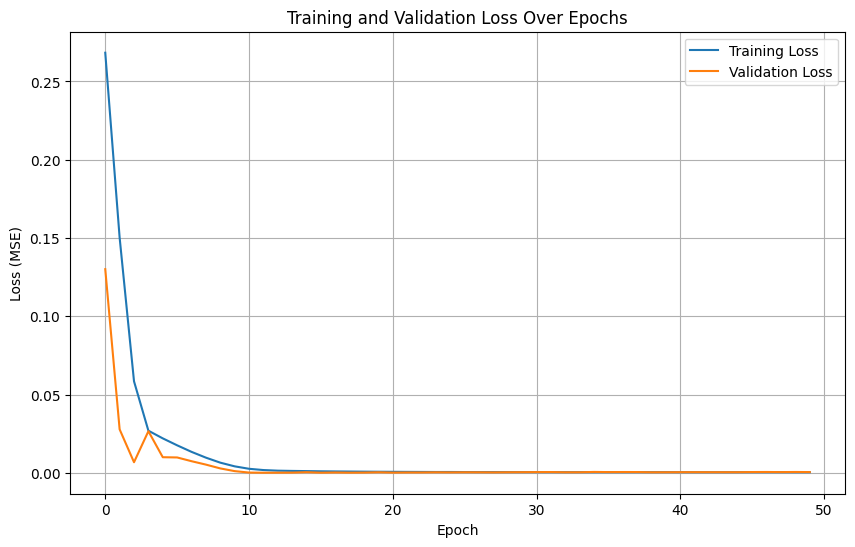

In [9]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

R-squared (R2) score on test set: 0.9765
Root Mean Squared Error (RMSE) on test set: 4.09


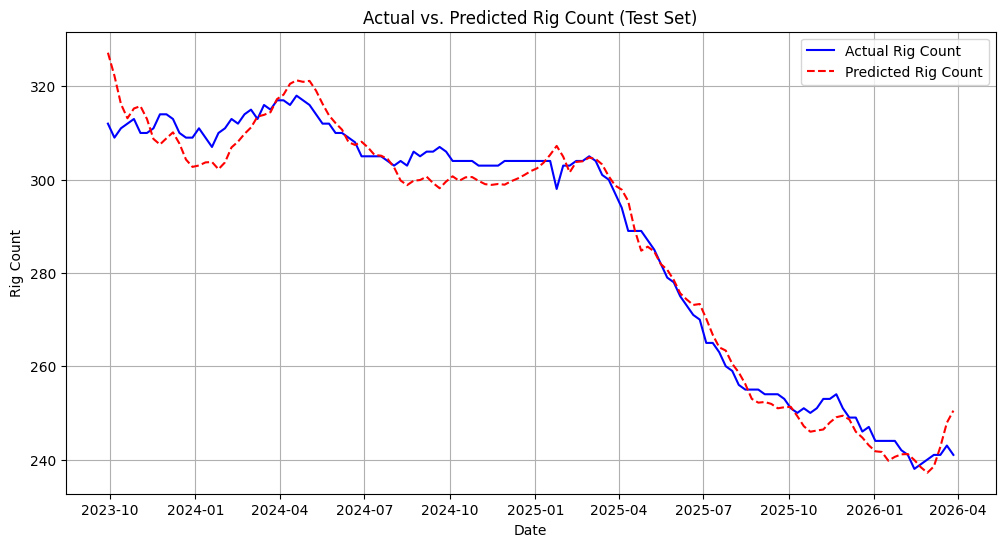

In [10]:
# --- Step 8: Evaluate the model ---

import matplotlib.pyplot as plt # Added this import statement

# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform the predictions and actual values to their original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Calculate evaluation metrics (e.g., R-squared, RMSE)
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))

print(f"\nR-squared (R2) score on test set: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE) on test set: {rmse:.2f}")

# Plot actual vs. predicted values
plt.figure(figsize=(12, 6))
# Dynamically adjust the starting index for plotting to match the length of y_test_actual
# This makes the plotting more robust if previous steps were not re-run correctly.
plot_dates = df.index[-len(y_test_actual):]

plt.plot(plot_dates, y_test_actual, label='Actual Rig Count', color='blue')
plt.plot(plot_dates, y_pred, label='Predicted Rig Count', color='red', linestyle='--')
plt.title('Actual vs. Predicted Rig Count (Test Set)')
plt.xlabel('Date')
plt.ylabel('Rig Count')
plt.legend()
plt.grid(True)
plt.show()

### Short-Term Forecasting

In [11]:
def forecast_future(model, X_test_scaled, scaler_X_features, scaler_y, time_steps, num_future_weeks):
    # Get the last 'time_steps' observations from the test set as the initial input sequence
    last_sequence = X_test_scaled[-time_steps:]

    future_predictions_scaled = []
    current_sequence = last_sequence.reshape(1, time_steps, X_test_scaled.shape[1]) # Reshape for model input

    for _ in range(num_future_weeks):
        # Predict the next step
        next_pred_scaled = model.predict(current_sequence, verbose=0)
        future_predictions_scaled.append(next_pred_scaled[0, 0])

        # Prepare the next input sequence:
        # Shift the window, drop the oldest observation, and append the new prediction

        # The new prediction is only for 'Rig_Count'. We need to supply WTI_Price and WTI_Price_24wk_MA.
        # For demonstration, we'll assume the WTI features for the future week are constant or use the last observed.
        # In a real-world scenario, you'd need a separate forecast for WTI prices.

        # For simplicity in this demo, let's assume WTI_Price and WTI_Price_24wk_MA for the forecasted week are the same as the last observed week.
        # Extract the last WTI_Price and WTI_Price_24wk_MA from the original scaled features (not the input sequence which only has Rig_Count)
        last_wti_features_scaled = current_sequence[0, -1, :2] # Last two features from the last timestep of the current sequence

        new_features_for_next_step = np.array([last_wti_features_scaled[0], last_wti_features_scaled[1], next_pred_scaled[0,0]])
        new_features_for_next_step_reshaped = new_features_for_next_step.reshape(1, 1, -1)

        current_sequence = np.append(current_sequence[:, 1:, :], new_features_for_next_step_reshaped, axis=1)

    # Inverse transform the scaled predictions
    future_predictions = scaler_y.inverse_transform(np.array(future_predictions_scaled).reshape(-1, 1))
    return future_predictions

# Define the number of weeks to forecast
num_future_weeks = 8 # Let's forecast for the next 8 weeks

# Generate future forecasts
future_forecast_rig_count = forecast_future(model, X_test_scaled, scaler_X_features, scaler_y, time_steps, num_future_weeks)

print(f"\nForecasted Rig Count for the next {num_future_weeks} weeks:")
for i, pred in enumerate(future_forecast_rig_count):
    print(f"Week {i+1}: {pred[0]:.2f}")



Forecasted Rig Count for the next 8 weeks:
Week 1: 250.39
Week 2: 251.76
Week 3: 258.92
Week 4: 262.73
Week 5: 269.34
Week 6: 274.69
Week 7: 281.58
Week 8: 288.20


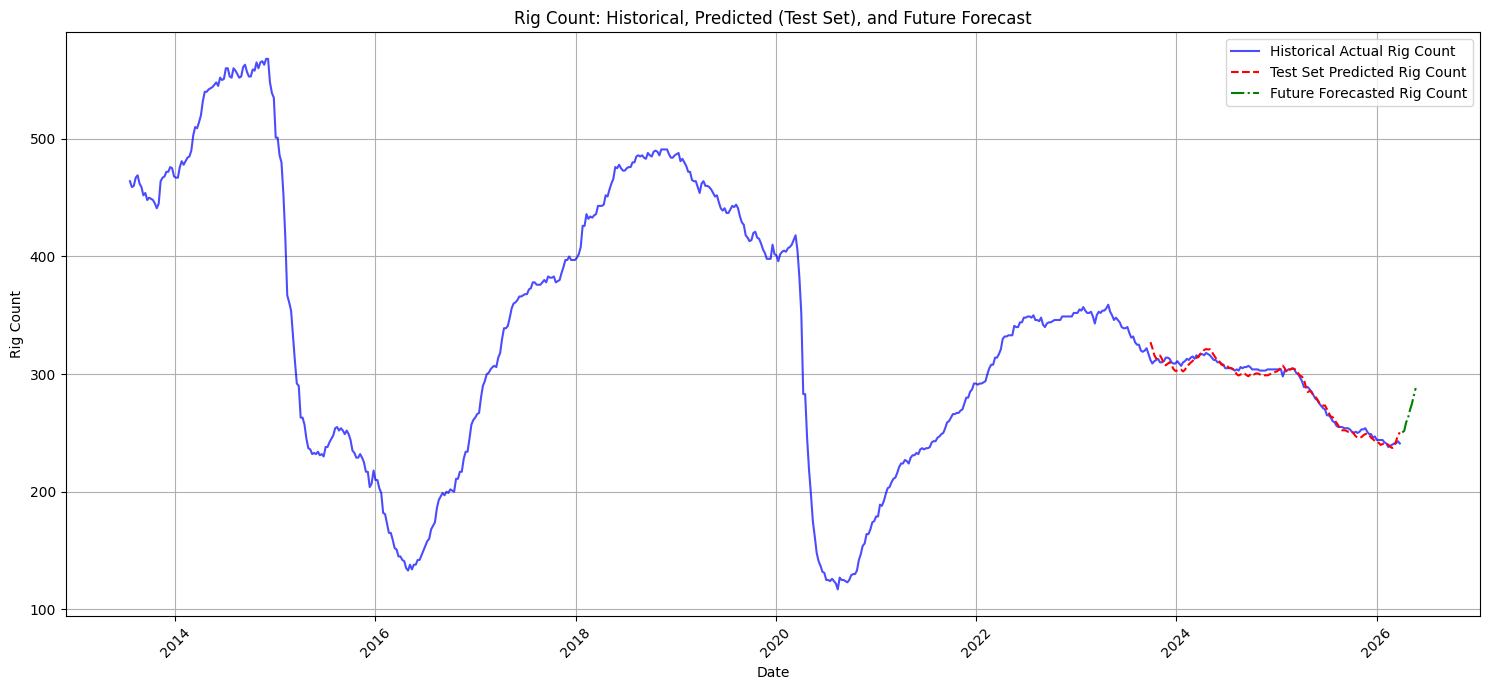

In [12]:
# Create future dates for plotting
last_date_in_df = df.index[-1]
future_dates = pd.date_range(start=last_date_in_df, periods=num_future_weeks + 1, freq='W')[1:] # Exclude the last known date

# Combine actual, predicted (test set), and forecasted values for plotting
all_dates = pd.to_datetime(df.index.tolist()[-len(y_train_scaled) - len(y_test_actual):]) # Start from the beginning of train/test data

# Get the actual rig counts for the plotting range (training + testing)
actual_rig_counts = scaler_y.inverse_transform(y_scaled[-len(y_train_scaled) - len(y_test_actual):])

# Extend plot_dates to include future_dates
plot_dates_with_forecast = df.index[-len(y_test_actual):].tolist() + future_dates.tolist()

# Extend y_pred to include future_forecast_rig_count
y_pred_with_forecast = np.concatenate((y_pred, future_forecast_rig_count))

# Plot historical actual, test set predictions, and future forecasts
plt.figure(figsize=(15, 7))
plt.plot(all_dates, actual_rig_counts, label='Historical Actual Rig Count', color='blue', alpha=0.7)
plt.plot(df.index[-len(y_test_actual):], y_pred, label='Test Set Predicted Rig Count', color='red', linestyle='--')
plt.plot(future_dates, future_forecast_rig_count, label='Future Forecasted Rig Count', color='green', linestyle='-.')

plt.title('Rig Count: Historical, Predicted (Test Set), and Future Forecast')
plt.xlabel('Date')
plt.ylabel('Rig Count')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()